# 📌 Introduction
- **Objective**: Predict whether a student will pass or fail based on **Study Hours** and **Attendance**.  
- **Dataset**: Contains student details with features like:
  - `Study_Hours`
  - `Attendance`
  - `Pass` (Target Variable: 1 = Pass, 0 = Fail)  
- **Approach**:
  - Perform **EDA** to understand data distribution and outliers.  
  - Train a **Logistic Regression model** to classify students.  
  - Evaluate performance using **accuracy, confusion matrix, and ROC-AUC**.  
  - Predict outcomes for new students.  

## 🔹 1. Data Preprocessing & EDA
- **Load dataset** and check for missing values.  
- **Identify outliers** using statistical methods and box plots.  
- **Visualize relationships** between `Study_Hours`, `Attendance`, and `Pass` using scatter plots.  

In [32]:
import numpy as np  # Numerical computations
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns  # Statistical data visualization
import scipy.stats as stats  # Statistical analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [6]:
path = 'Students_data.csv'
df = pd.read_csv(path)  

In [8]:
df.head(3)

,id,first_name,last_name,Study_Hours,Attendance,Pass
0,1,Judah,Brayshaw,8,92.79,1
1,2,Cassy,Lutsch,42,84.34,0
2,3,Fara,Oland,34,35.67,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1000 non-null   int64  
 1   first_name   1000 non-null   object 
 2   last_name    1000 non-null   object 
 3   Study_Hours  1000 non-null   int64  
 4   Attendance   1000 non-null   float64
 5   Pass         1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [14]:
df.describe()

,id,Study_Hours,Attendance,Pass
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,38.547000,55.93601,0.505000
std,288.819436,17.937992,25.45264,0.500225
min,1.000000,7.000000,10.02000,0.000000
25%,250.750000,23.000000,33.91250,0.000000
50%,500.500000,39.000000,56.56000,1.000000
75%,750.250000,53.000000,78.42750,1.000000
max,1000.000000,70.000000,99.71000,1.000000


In [16]:
df.isnull().sum()

id             0
first_name     0
last_name      0
Study_Hours    0
Attendance     0
Pass           0
dtype: int64

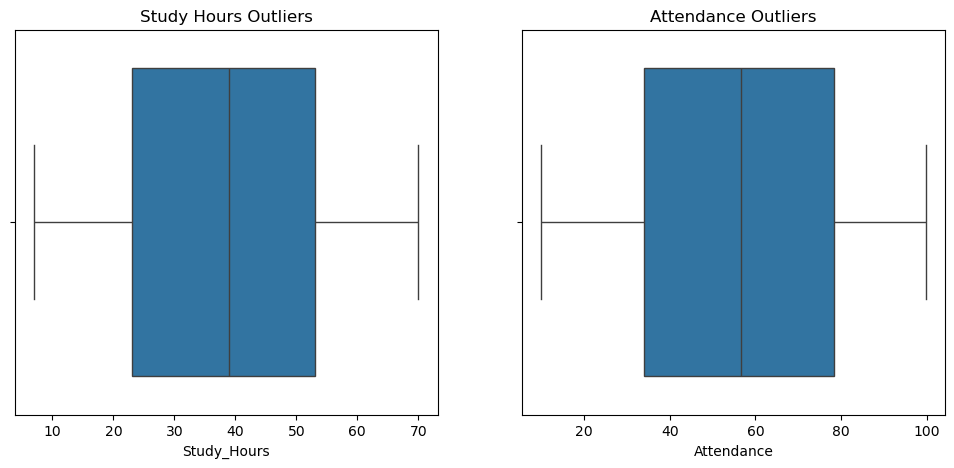

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["Study_Hours"])
plt.title("Study Hours Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["Attendance"])
plt.title("Attendance Outliers")

plt.show()

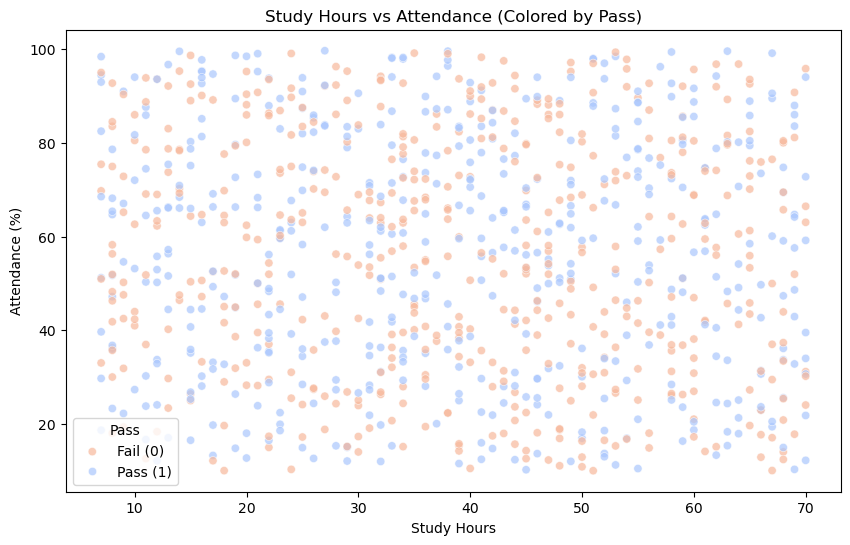

In [22]:
plt.figure(figsize=(10, 6))

# Scatter plot with hue as 'Pass' (0 or 1)
sns.scatterplot(data=df, x="Study_Hours", y="Attendance", hue="Pass", palette="coolwarm", alpha=0.7)

# Add labels and title
plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("Study Hours vs Attendance (Colored by Pass)")
plt.legend(title="Pass", labels=["Fail (0)", "Pass (1)"])

# Show the plot
plt.show()

## 🔹 2. Model Training
- **Feature Selection**:  
  - `Study_Hours` and `Attendance` as input features (`X`).  
  - `Pass` as the target (`y`).  
- **Data Splitting**: Train-test split (80% training, 20% testing).  
- **Train Logistic Regression Model**:
  - `LogisticRegression().fit(X_train, y_train)`  
  - Uses sigmoid function to classify students.  

In [24]:
# Select features and target
X = df[["Study_Hours", "Attendance"]]
y = df["Pass"]

In [34]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## 🔹 3. Model Evaluation
- **Accuracy Score**: Measures the proportion of correct predictions.  
- **Classification Report**: Includes Precision, Recall, and F1-score.  
- **Confusion Matrix**:
  - ✅ **True Positives (TP)**: Correctly predicted passes.  
  - ✅ **True Negatives (TN)**: Correctly predicted failures.  
  - ❌ **False Positives (FP)**: Incorrectly predicted passes.  
  - ❌ **False Negatives (FN)**: Incorrectly predicted failures.  

In [36]:
# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.45

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.37      0.40        97
           1       0.47      0.52      0.50       103

    accuracy                           0.45       200
   macro avg       0.45      0.45      0.45       200
weighted avg       0.45      0.45      0.45       200



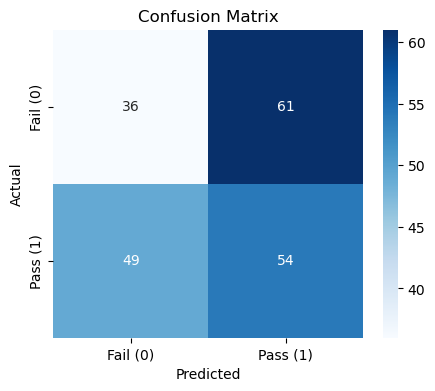

In [38]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Fail (0)", "Pass (1)"], yticklabels=["Fail (0)", "Pass (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [40]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.45


In [46]:
TN, FP, FN, TP = conf_matrix.ravel()
print(f"True Positives: {TP}, True Negatives: {TN}, False Positives: {FP}, False Negatives: {FN}")

True Positives: 54, True Negatives: 36, False Positives: 61, False Negatives: 49


## 🔹 4. ROC Curve & AUC Score
- Measures model performance across different threshold values.  
- **Higher AUC = Better model separation** between pass/fail students.  

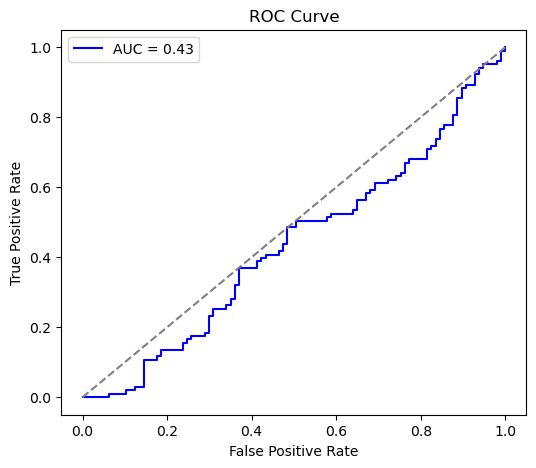

In [48]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 🔹 5. Predicting New Student Outcomes
- Used a function to **take Study Hours & Attendance as input** and predict pass/fail.  
- **Fixed warning** by ensuring input is passed as a Pandas DataFrame with correct column names.  

In [54]:
import pandas as pd

# Function to predict pass/fail for a new student
def predict_student_outcome(study_hours, attendance):
    # Convert input to DataFrame with correct feature names
    new_data = pd.DataFrame([[study_hours, attendance]], columns=["Study_Hours", "Attendance"])
    
    # Predict pass/fail (0 = Fail, 1 = Pass)
    prediction = model.predict(new_data)
    
    # Print result
    if prediction[0] == 1:
        print(f"✅ The student is predicted to PASS.")
    else:
        print(f"❌ The student is predicted to FAIL.")

In [60]:
# Example Usage
predict_student_outcome(10, 15)  # Example: 30 study hours, 85% attendance

✅ The student is predicted to PASS.


# 📌 Conclusion
- The model **successfully predicts** student pass/fail outcomes using `Study_Hours` & `Attendance`.  
- **Key Takeaways**:
  - ✅ **Higher study hours & attendance = Higher chance of passing**.  
  - Model is effective but can be **improved** by adding more features like previous grades, study patterns, or learning styles.  
- **Future Enhancements**:
  - Test with **other models** (e.g., Decision Trees, Random Forest).  
  - Collect **more data** for better generalization.  
  - Implement **hyperparameter tuning** for improved accuracy.  